**Step 1: Understanding the Problem and the Data**

The first step in any data analysis project is to fully understand the problem we're solving and the data we have. This includes asking questions like:

* What is the goal or problem we are trying to solve?
* What variables are present in the dataset and what do they represent?
* What types of data are available (numerical, categorical, text etc.)?
* Are there any data quality issues or limitations?

We are trying to explore a given dataset and check the quality by applying RGPD principles, cleaning it and transforming it , to have created by the end a structured and secure PostgreSQL base (staging/core)

we have both categorial and numerical types of data

and we have multiple missing values and duplicated data


**Step 2: Importing and Inspecting the Data**

The next step is to load the dataset into tools like Python or R and inspect it. These checks give a basic understanding of the dataset.

* Load the dataset properly.
* Check the number of rows and columns.
* Identify missing values.
* Verify the data type of each variable.
* Look for errors, invalid values or unusual data points.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from data_profiling import ProfileReport
%matplotlib inline

pd.set_option("display.max_columns", 25)
df = pd.read_csv("../data/raw/store-data.csv", encoding="latin-1")


print("dataset first 5 lines \n")
display(df.head())
print("\n\ndataset last 5 lines \n")
display(df.tail())

print("\n\ndataset number of lines & columns \n")
display(df.shape)

print("\n\ndataset descriptive stats \n")
display(df.describe())

print("\n\ndataset missing values count \n")
display(df.isna().sum().sort_values(ascending=False))
print("\n\ndataset missing values percentage  \n")
display(df.isna().mean() * 100)



dataset first 5 lines 



,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2.0,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2.0,0.20,2.5164




dataset last 5 lines 



,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
10059,1281,CA-2016-160815,9/5/2016,9/6/2016,First Class,TR-21325,TOBY RITTER,Consumer,United States,Cedar Rapids,Iowa,52402.0,Central,TEC-PH-10003505,Technology,Phones,Geemarc AmpliPOWER60,278.400,3.0,0.0,80.7360
10060,7699,CA-2017-151799,12/14/2017,12/18/2017,Standard Class,BF-11170,BEN FERRER,Home Office,United States,Lawrence,Massachusetts,1841.0,East,OFF-ST-10002790,Office Supplies,Storage,Safco Industrial Shelving,73.850,1.0,0.0,2.2155
10061,8597,CA-2014-111934,5/5/2014,5/7/2014,First Class,GD-14590,GIULIETTA DORTCH,Corporate,United States,Arlington,Virginia,22204.0,South,OFF-PA-10000474,Office Supplies,Paper,Easy-staple paper,35.440,1.0,0.0,16.6568
10062,4962,CA-2014-156587,3/7/2014,3/8/2014,First Class,AB-10015,NaN,Consumer,United States,Seattle,Washington,98103.0,West,FUR-CH-10004477,Furniture,Chairs,"Global Push Button Manager's Chair, Indigo",48.712,1.0,0.2,5.4801
10063,3998,CA-2015-105627,3/8/2015,3/12/2015,Standard Class,DK-12895,DANA KAYDOS,Consumer,United States,Kenosha,Wisconsin,53142.0,Central,OFF-AR-10002704,Office Supplies,Art,Boston 1900 Electric Pencil Sharpener,14.980,1.0,0.0,4.4940




dataset number of lines & columns 



...

,Row ID,Sales,Quantity,Discount,Profit
count,10064.000000,9.863000e+03,9865.000000,10064.000000,10064.000000
mean,4994.397059,1.950322e+03,3.780233,0.157501,28.571309
std,2885.848580,4.410673e+04,2.240134,0.210586,233.509461
min,1.000000,4.440000e-01,-5.000000,0.000000,-6599.978000
25%,2496.750000,1.729000e+01,2.000000,0.000000,1.724800
50%,4989.500000,5.450000e+01,3.000000,0.200000,8.643600
75%,7494.250000,2.107600e+02,5.000000,0.200000,29.331600
max,9994.000000,1.131924e+06,14.000000,1.500000,8399.976000




dataset missing values count 



Customer Name    351
Ship Mode        301
Sales            201
Postal Code      200
Quantity         199
Ship Date        101
Order ID           0
Row ID             0
Order Date         0
Country            0
City               0
Segment            0
Customer ID        0
Region             0
State              0
Product ID         0
Category           0
Product Name       0
Sub-Category       0
Discount           0
Profit             0
dtype: int64



dataset missing values percentage  



Row ID           0.000000
Order ID         0.000000
Order Date       0.000000
Ship Date        1.003577
Ship Mode        2.990859
Customer ID      0.000000
Customer Name    3.487679
Segment          0.000000
Country          0.000000
City             0.000000
State            0.000000
Postal Code      1.987281
Region           0.000000
Product ID       0.000000
Category         0.000000
Sub-Category     0.000000
Product Name     0.000000
Sales            1.997218
Quantity         1.977345
Discount         0.000000
Profit           0.000000
dtype: float64

**Step 3: Handling Missing Data**

Missing data is common in many datasets and can affect the quality of analysis. During EDA, it is important to identify and handle missing values properly to avoid incorrect results.

* Understand why data is missing, as this helps in selecting the right approach.
* Decide whether to remove or fill missing values, since removal can cause bias while imputation preserves data.
* Use suitable imputation methods such as mean, median, regression or machine learning techniques like KNN or decision trees.
* Consider the impact of missing data, as it can still introduce uncertainty even after imputation.




In [13]:
# we have six columns where some values are missing but it is observed that some of these values are not missing in other rows like Customer Name, Ship Mode, Sales, Postal Code, Quantity, Ship Date
# so my approach will be to fill them by copying from tha valid entries as for the remaining after all will be dropped
# and then check the consistency

**Step 4: Exploring Data Characteristics**

After handling missing data, the next step is to examine the main characteristics of the dataset. This helps us understand how the data is distributed, detect unusual values and identify potential issues before further analysis.

* Check data distribution to understand how values are spread across the dataset.
* Measure central tendency using mean, median and mode to find the typical value of the data.
* Measure variability using standard deviation to see how much the values vary.
* Analyze distribution shape using skewness and kurtosis.
* Identify outliers or anomalies that may affect the analysis.

In [14]:
# # display(df["Row ID"].nunique())
# display(df["Category"].nunique())
# display(df["State"].nunique())
# display(df["City"].nunique())
# display(df["Sub-Category"].nunique())
display(df["Row ID"].nunique())
display(df["Sub-Category"].unique())

custom = df.groupby("Customer ID")["Customer Name"].nunique()
display(custom[custom > 1 ])

prod = df.groupby("Product ID")["Product Name"].nunique()
display(prod[prod > 1 ])

df[df["Row ID"].duplicated(keep=False)].isna

display(df["Category"].value_counts())
display(df["Sub-Category"].value_counts())
display(df["City"].value_counts())

9994

array(['Bookcases', 'Chairs', 'Labels', 'Tables', 'Storage',
       'Furnishings', 'Art', 'Phones', 'Binders', 'Appliances', 'Paper',
       'Accessories', 'Envelopes', 'Fasteners', 'Supplies', 'Machines',
       'Copiers'], dtype=object)

Customer ID
AG-10495    2
BF-11170    2
BH-11710    2
BK-11260    2
BT-11680    2
DK-12895    2
ED-13885    2
EH-13765    2
FC-14245    2
GD-14590    2
JK-15370    2
KM-16720    2
MT-18070    2
NZ-18565    2
PK-18910    2
PP-18955    2
RB-19465    2
TR-21325    2
Name: Customer Name, dtype: int64

Product ID
FUR-BO-10002213    2
FUR-CH-10001146    2
FUR-FU-10001473    2
FUR-FU-10004017    2
FUR-FU-10004091    2
FUR-FU-10004270    2
FUR-FU-10004848    2
FUR-FU-10004864    2
OFF-AP-10000576    2
OFF-AR-10001149    2
OFF-BI-10002026    2
OFF-BI-10004632    2
OFF-BI-10004654    2
OFF-PA-10000357    2
OFF-PA-10000477    2
OFF-PA-10000659    2
OFF-PA-10001166    2
OFF-PA-10001970    2
OFF-PA-10002195    2
OFF-PA-10002377    2
OFF-PA-10003022    2
OFF-ST-10001228    2
OFF-ST-10004950    2
TEC-AC-10002049    2
TEC-AC-10002550    2
TEC-AC-10003832    2
TEC-MA-10001148    2
TEC-PH-10001530    2
TEC-PH-10001795    2
TEC-PH-10002200    2
TEC-PH-10002310    2
TEC-PH-10004531    2
Name: Product Name, dtype: int64

Category
Office Supplies    5942
Furniture          2095
Technology         1826
office supplies     123
furniture            42
technology           36
Name: count, dtype: int64

Sub-Category
Binders        1532
Paper          1378
Furnishings     966
Phones          899
Storage         853
Art             803
Accessories     780
Chairs          622
Appliances      469
Labels          366
Tables          321
Envelopes       254
Bookcases       228
Fasteners       220
Supplies        190
Machines        115
Copiers          68
Name: count, dtype: int64

City
New York City    896
Los Angeles      741
Philadelphia     527
San Francisco    507
Seattle          427
                ... 
RICHMOND           1
Melbourne          1
PLAINFIELD         1
COSTA MESA         1
YUMA               1
Name: count, Length: 633, dtype: int64

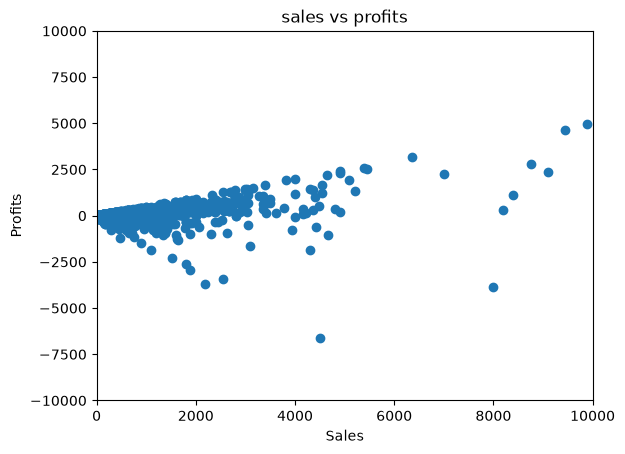

In [22]:
plt.figure()
plt.scatter(df["Sales"],df["Profit"])
plt.title("sales vs profits")
plt.xlabel("Sales")
plt.xlim(0, 10000) 
plt.ylabel("Profits")
plt.ylim(-10000, 10000) 
plt.show()

In [16]:
profile = ProfileReport(df, title="Profiling Report")
profile.to_file("../reports/report.html")

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 35.07it/s]
